# Cluster Analysis

In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.feather as feather
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import scipy.cluster.hierarchy as hierarchy
from sklearn.metrics import silhouette_score
import sys

# python source path
sys.path.append('../Src/')
# Set seed
SEED = 1776

# custom python 
import zscore_anomaly
import hierarchy_clustering as hc
import chicago_crime_utilities as utils
import chicago_crime_plot as plot

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Scipy": scipy.__version__,
    "Seaborn": sns.__version__, 
    "Matplot": plt.matplotlib.__version__,
    "Sk-Learn": sys.modules['sklearn'].__version__,
    "PyArrow": pa.__version__,
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# Remove scientific notation
np.set_printoptions(suppress=True, precision=4, linewidth=100)
# reset options
pd.set_option('display.max_rows', None)

    Library Version
0    Python  3.13.9
1    Pandas   2.3.3
2     NumPy   2.3.4
3     Scipy  1.16.3
4   Seaborn  0.13.2
5   Matplot  3.10.7
6  Sk-Learn   1.8.0
7   PyArrow  22.0.0


In [2]:
# PyArrow's version of the 'arrow' backend
df = feather.read_feather('../Data/crime_data.feather', memory_map=True, types_mapper=pd.ArrowDtype)
# display
df.head()

,case_number,date,block,iucr,primary_description,secondary_description,index_code,primary_type,description,location_description,...,y_coordinate,era,month,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location
8265318,01G050460,2001-01-24 20:45:00,072XX S RIDGELAND AV,1811,NARCOTICS,POSSESS - CANNABIS 30 GRAMS OR LESS,N,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,...,1857566,pre_covid,January,Wednesday,Q1,2001-Q1,Night,Drug Abuse Violations,False,Grand Crossing
7080787,03J493690,2003-07-12 17:00:00,075XX S DOBSON AVE,0890,THEFT,FROM BUILDING,I,THEFT,FROM BUILDING,APARTMENT,...,1854276,pre_covid,July,Saturday,Q3,2003-Q3,Evening,Larceny - Theft,True,Gresham
6396203,04X245238,2004-12-13 21:15:00,006XX N RIDGEWAY AVE,2024,NARCOTICS,POSSESS - HEROIN (WHITE),N,NARCOTICS,POSS: HEROIN(WHITE),SIDEWALK,...,1903996,pre_covid,December,Monday,Q4,2004-Q4,Night,Drug Abuse Violations,False,Harrison
5818733,07C115980,2006-03-31 09:15:00,026XX N NARRAGANSETT AVE,0610,BURGLARY,FORCIBLE ENTRY,I,BURGLARY,FORCIBLE ENTRY,APARTMENT,...,1916864,pre_covid,March,Friday,Q1,2006-Q1,Morning,Burglary,True,Grand Central
5312174,07HN36467,2007-05-25 14:51:00,022XX N LA CROSSE AVE,1812,NARCOTICS,POSSESS - CANNABIS MORE THAN 30 GRAMS,N,NARCOTICS,POSS: CANNABIS MORE THAN 30GMS,RESIDENCE,...,1914371,pre_covid,May,Friday,Q2,2007-Q2,Afternoon,Drug Abuse Violations,False,Grand Central


In [3]:
# remove incomplete 2026 data
max_year = df.date.max().year
df = df.loc[df.date.dt.year < max_year,].reset_index(drop=True).copy()

In [4]:
# NaNs
utils.any_nans(df)

--- Missing Values Found (Total Rows: 8,476,442) ---
                       Count Percentage
location_description   15659    0.1847%
primary_description    15257    0.1800%
secondary_description  15257    0.1800%
index_code             15257    0.1800%


#### Calculating the Z-score highlights specialized anomalies

* A Z-score of 3.0
    * The value is higher than about 99.87% of all values in a normal distribution
    * It’s an extreme outlier
* A Z‑score of 2 means:
    * The value is higher than about 97.7% of all values in a normal distribution
    * That year’s count is significantly higher than the historical average
* A Z-score of -1:
    * The value is lower than about 84% of all values
    * It’s a mild decrease, not extreme - appears as light blue in the heatmap
* A Z-score of -2:
    * The value is lower than about 97.7% of all values
    * A significant drop below the historical average - appears as medium blue
* A Z-score of -3:
    * The value is lower than about 99.87% of all values
    * An extreme low outlier - appears as deep blue; the mirror image of a deep red spike

##### User Function(s)

In [5]:
def heat_map(data: pd.DataFrame, typ: str='Indexed', figsize: tuple=(16, 6)) -> None:
    # Create the Heatmap
    plt.figure(figsize=figsize)
    sns. heatmap(
        data,
        cmap="RdBu_r",          # Red for high Z-scores, Blue for low
        center=0,               # White represents the mean
        annot=True,             # Change to False if you don't want to see the numbers
        fmt=".2f",              # format as integers
        annot_kws={"size": 8}, # change font size here
        linewidths=.5
    )
    plt.title(f"Z‑Score Heatmap ({typ} Crimes)", fontsize=16)
    plt.xlabel("Year", fontsize=10)
    plt.ylabel("Crime Type", fontsize=12)
    plt.yticks(fontsize=10, rotation=0, ha='right')
    plt.xticks(fontsize=10, rotation=45, ha='right')
    plt.show()

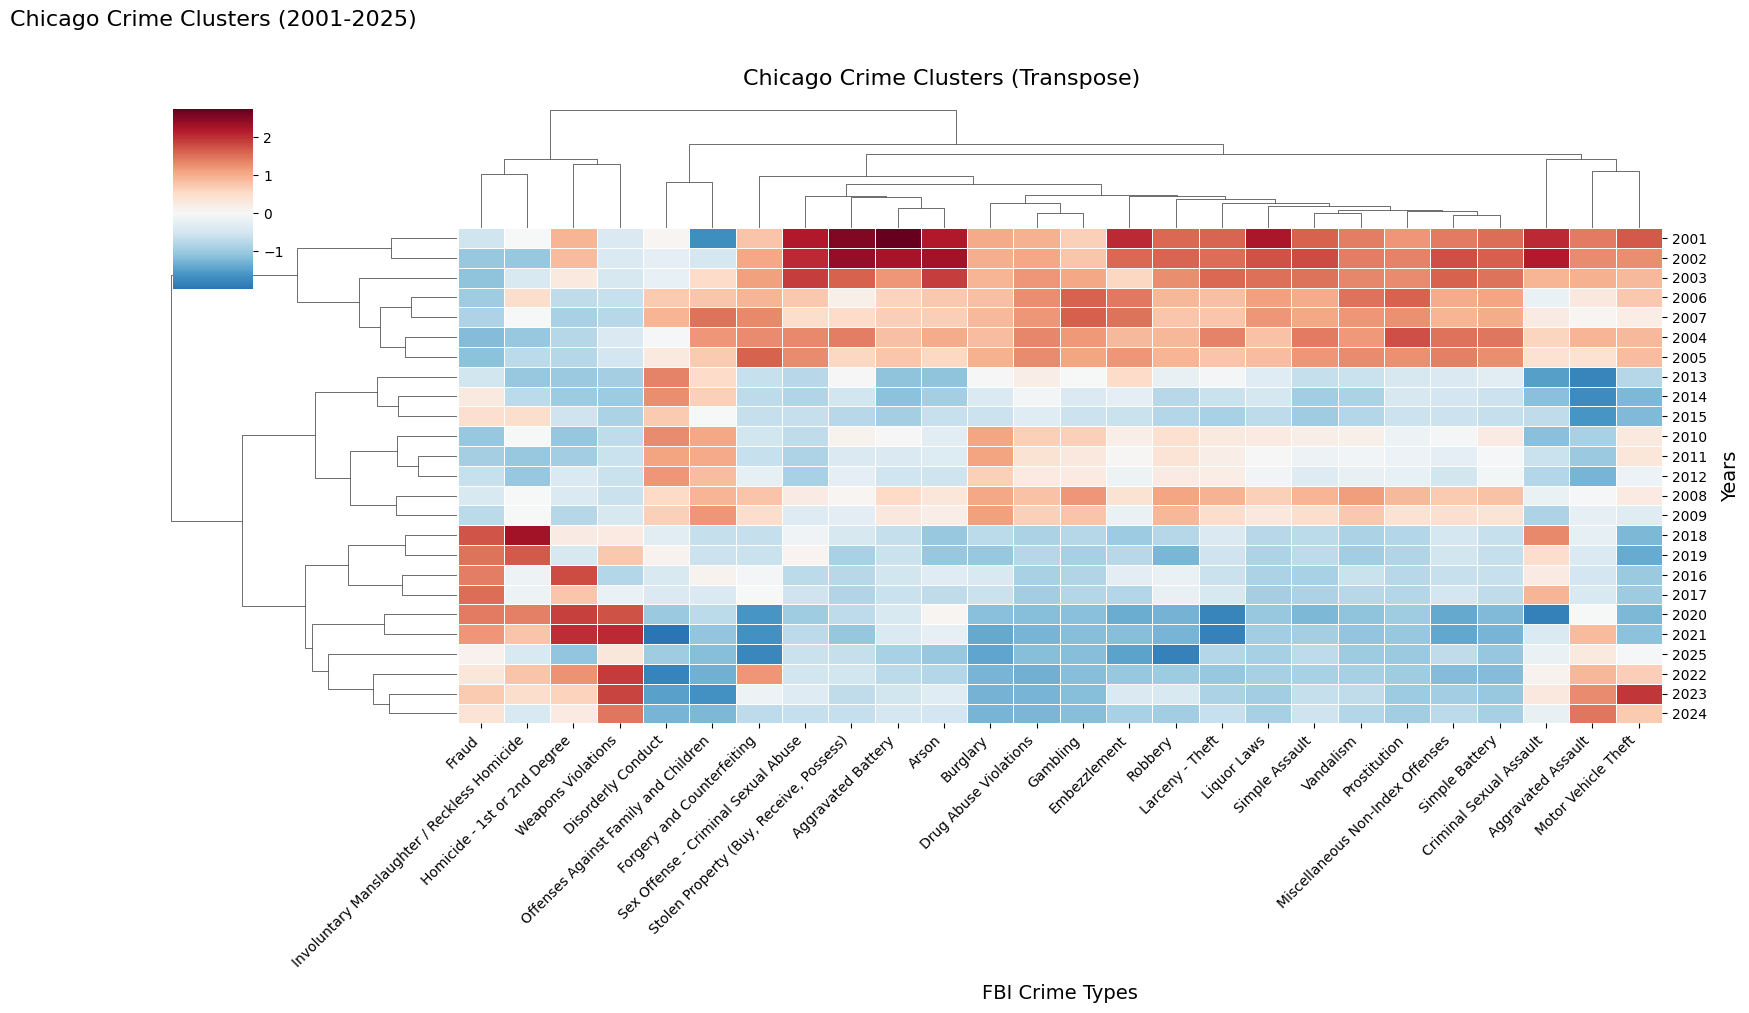

In [6]:
# Z score (Indexed & Non-Indexed
z_df = zscore_anomaly.zscore_anomaly(data=df, time_col='year', category_col='fbi_code_desc')

# Create the clustermap
g = sns.clustermap(
    z_df.T, 
    cmap="RdBu_r", 
    center=0, 
    figsize=(16, 10),
    # row_cluster=True,  # Keep years in chronological order (on the Y-axis)
    col_cluster=True,  # Cluster the crimes together (on the X-axis)
    linewidths=0.5,
    xticklabels=True,   # Ensure all crime names show up
    yticklabels=True    # Ensure all years show up
)

# Rotate X-axis labels for readability
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.title("Chicago Crime Clusters (2001-2025)", fontsize=16, pad=60)
plt.suptitle("Chicago Crime Clusters (Transpose)", fontsize=16, y=1.02)
g.ax_heatmap.set_xlabel('FBI Crime Types', fontsize=14, labelpad=10)
g.ax_heatmap.set_ylabel('Years', fontsize=14, labelpad=10)

# Save the figure with high resolution and tight cropping
plt.savefig("../Image/cluster_Heatmap_analysis.png", dpi=600, bbox_inches='tight')
plt.show()

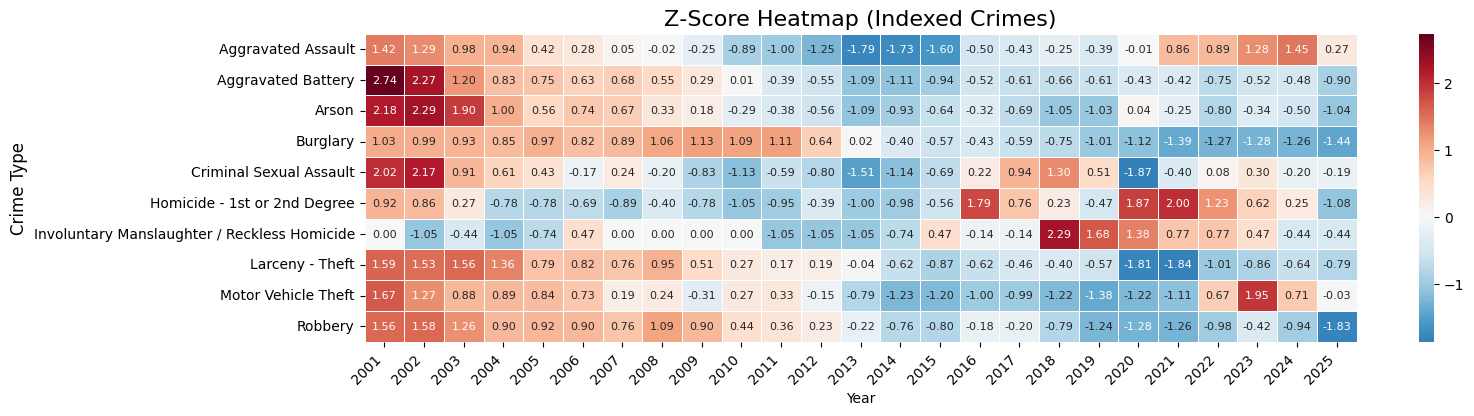

In [7]:
# Calculate z-scores Indexed Crime
bool_mask = df.fbi_index_code == True
z_df_i = zscore_anomaly.zscore_anomaly(data=df[bool_mask], time_col='year', category_col='fbi_code_desc')
# plot
heat_map(z_df_i, 'Indexed', (16,4))

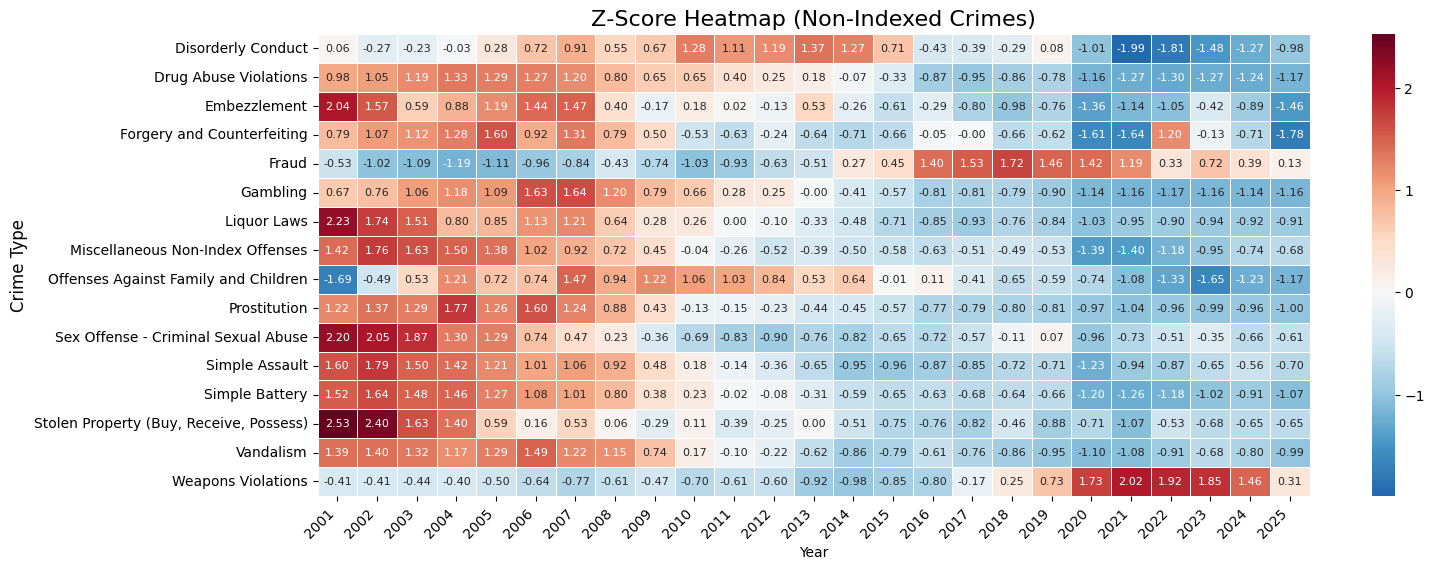

In [8]:
# Calculate z-scores Non-Indexed Crime
bool_mask = df.fbi_index_code == False
z_df_n = zscore_anomaly.zscore_anomaly(data=df[bool_mask],time_col='year', category_col='fbi_code_desc')
heat_map(z_df_n, 'Non-Indexed')

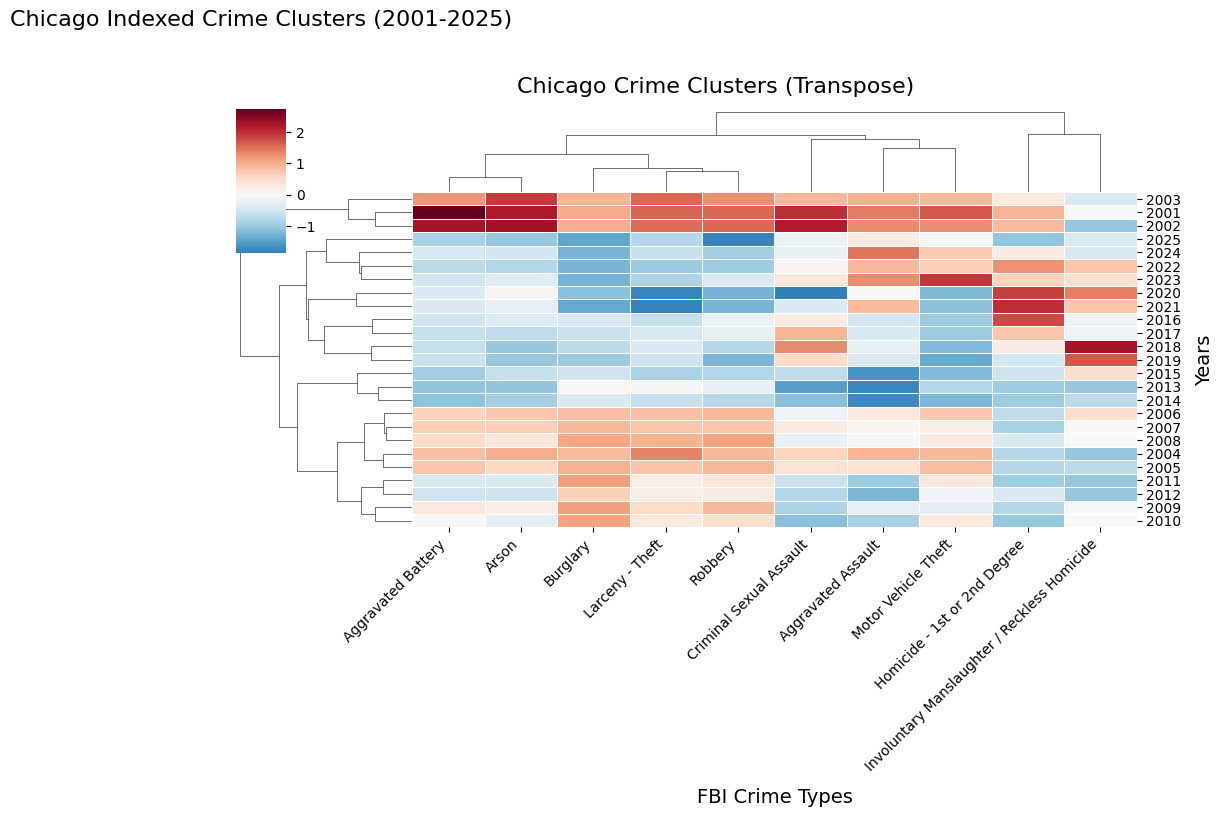

In [9]:
# Z score (Indexed)
# Create the clustermap
g = sns.clustermap(
    z_df_i.T, 
    cmap="RdBu_r", 
    center=0, 
    figsize=(10, 8),
    # row_cluster=True,  # Keep years in chronological order (on the Y-axis)
    col_cluster=True,  # Cluster the crimes together (on the X-axis)
    linewidths=0.5,
    xticklabels=True,   # Ensure all crime names show up
    yticklabels=True    # Ensure all years show up
)

# Rotate X-axis labels for readability
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.title("Chicago Indexed Crime Clusters (2001-2025)", fontsize=16, pad=60)
plt.suptitle("Chicago Crime Clusters (Transpose)", fontsize=16, y=1.02)
g.ax_heatmap.set_xlabel('FBI Crime Types', fontsize=14, labelpad=10)
g.ax_heatmap.set_ylabel('Years', fontsize=14, labelpad=10)

# Save the figure with high resolution and tight cropping
plt.savefig("../Image/cluster_index_analysis.png", dpi=600, bbox_inches='tight')
plt.show()

**Note:**
1. The Color Intensity (The Values)
* Since you are using Z-scores, look at the color first:
  - Deep Red: The crime count for that specific year was significantly above its historical average.
    - Deep Blue: The crime count for that specific year was significantly below its historical average.
    - White/Light Colors: The crime count was "normal" or very close to the 25-year mean.

2. The Dendrogram (The "Tree" Structure)
* The branches on the top (or side) tell you how similar items are.
* Close Neighbors: If two crime types are connected by a short "U-shaped" branch, they have very similar patterns over the 25-year period.
* Branch Length: The longer the vertical lines of the branch before they join, the less similar those two groups are.

3. Reading the "Clusters" (The Groups)
* The "Legacy" pattern (maps to **Cluster 3** in the final output): Crimes like Burglary, Larceny–Theft, and Robbery that were elevated in the early 2000s but have trended downward since. These appear Red on the left side of the heatmap and Blue on the right.
* The "Modern Surge" pattern (maps to **Cluster 2** in the final output): Crimes like Aggravated Assault and Motor Vehicle Theft that were below average for years but have surged since 2016–2020. These appear Blue in the middle years and Red toward the right.
* he "Lethal Violence" pattern (maps to **Cluster 1** in the final output): Homicide and Involuntary Manslaughter are tightly correlated throughout the full 25-year period, spiking sharply in 2020–2021 and partially recovering since.

4. Reading the X and Y Axis Together
* To find a specific "Anomaly," look for a single "pop" of color that breaks a trend.
* Vertical Red Streaks: If you see a vertical column of red across many crimes for a single year (like 2020), it suggests an External Event (like the Pandemic or civil unrest) affected almost everything at once.
* Horizontal Red Streaks: If one crime type is red across many years, it shows a long-term sustained increase for that specific category.

5. Why the "Rotation" Helps
* By rotating the plot, you can now scan horizontally to see which crimes behave similarly in the same year, and scan vertically to see how a single crime's "fortune" has changed from 2001 to 2025.

**Tip: The "Pivot Point"**
* Look for where the colors flip from Blue to Red. In Chicago's data, the clearest pivot occurs around 2020, where the pandemic-era disruption is visible across almost all crime types simultaneously. A secondary, more gradual shift is visible around 2016–2017 in the Modern Surge crimes (Aggravated Assault, Motor Vehicle Theft), though this is less dramatic than the 2020 event.

### Clustering

In [10]:
# Display Indexed Crimes ONLY
z_df_i.head()

year,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
fbi_code_desc,,,,,,,,,,,,,,,,,,,,,
Aggravated Assault,1.421331,1.286647,0.975359,0.938789,0.424137,0.284102,0.050413,-0.024511,-0.248389,-0.892372,...,-0.504377,-0.433021,-0.246605,-0.390208,-0.012023,0.859406,0.894192,1.279512,1.451657,0.268939
Aggravated Battery,2.738510,2.268336,1.203393,0.831564,0.753202,0.627039,0.684635,0.547893,0.288122,0.009936,...,-0.517833,-0.611868,-0.655359,-0.606775,-0.425366,-0.415179,-0.748218,-0.518225,-0.481395,-0.898674
Arson,2.184989,2.291361,1.901329,1.004762,0.564077,0.741364,0.670450,0.326006,0.184176,-0.291967,...,-0.322359,-0.687064,-1.046704,-1.031508,0.042346,-0.251444,-0.798502,-0.337555,-0.499646,-1.041638
Burglary,1.034741,0.985819,0.927514,0.853319,0.970805,0.823290,0.890104,1.060265,1.128955,1.085789,...,-0.432275,-0.593427,-0.750326,-1.014076,-1.124180,-1.386679,-1.269819,-1.283331,-1.262061,-1.444109
Criminal Sexual Assault,2.018673,2.167458,0.914228,0.610935,0.427815,-0.173049,0.238972,-0.195939,-0.831138,-1.134431,...,0.221805,0.937118,1.297637,0.513653,-1.866912,-0.396227,0.078742,0.296197,-0.201661,-0.190216


### Hierarchical Clustering Linkage Methods
* In hierarchical clustering, choosing the right linkage method is just as important as choosing the distance metric (like Euclidean or Manhattan). The linkage determines the "shape" of the clusters and the algorithm's sensitivity to outliers. These linkage methods work in practice; we need to examine the step-by-step logic of the Agglomerative (Bottom-Up) algorithm. This is the most common way hierarchical clustering is implemented.
* Agglomerative (Bottom-Up) Hierarchical Clustering is a widely used unsupervised machine learning algorithm that builds a nested hierarchy of clusters by iteratively merging the closest pairs of data points. Unlike k-means, it does not require specifying the number of clusters in advance, and the results are often visualized as a dendrogram. 
* `Linkage method choice:` The choice of linkage method in hierarchical clustering is a foundational decision that directly dictates how distances between clusters are calculated, which subsequently defines the structure and quality of the final clustering. 
    * cluster shape
    * sensitivity to noise
    * chaining vs. compactness
    * dendrogram height structure
    * number of clusters detected
#### 1. Specifying the Linkage Criterion: Linkage methods dictate how the algorithm decides which clusters to merge at each step.
[scipy.cluster.hierarchy.linkage](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html)

#### 2. Specifying the Distance Metric: The distance metric defines the "proximity" between two single observations in your dataset.
[scipy.spatial.distance.cdist](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cdist.html)

##### Note:
* Distance = 0: This implies $r = 1$. The two categories are perfectly positively correlated. 
* Distance = 1: This implies $r = 0$. There is no linear relationship at all. These categories provide completely independent information.
* Distance = 2: This implies $r = -1$. They are perfectly negatively correlated. When one category spikes in Z-score, the other drops significantly.

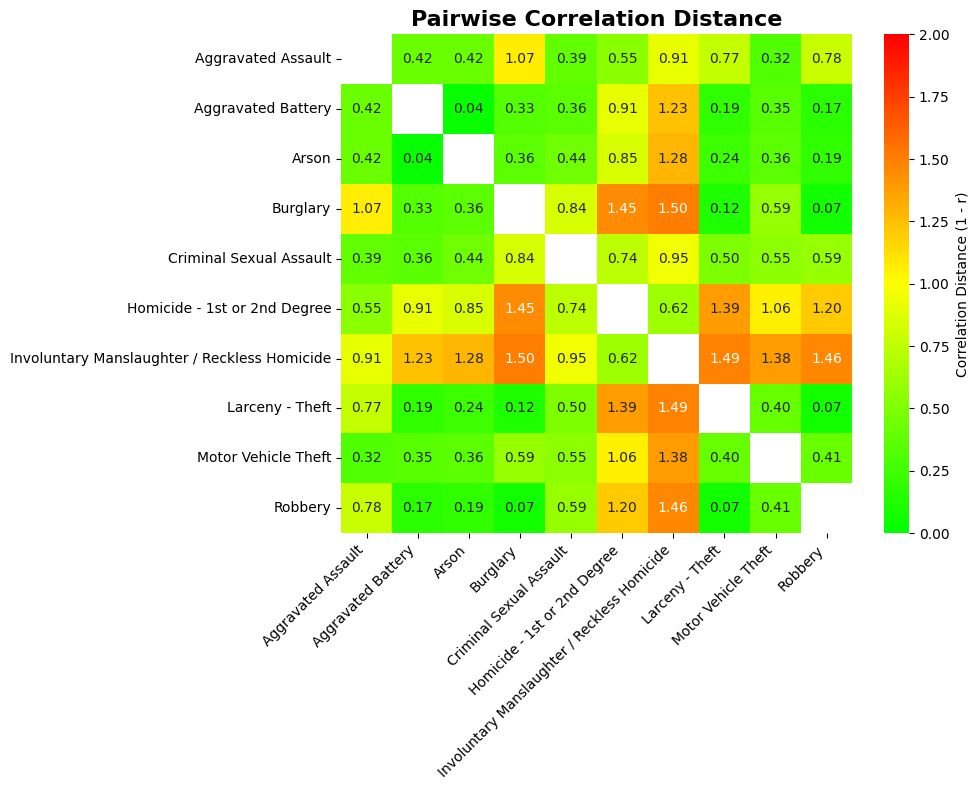

In [11]:
# Indexed Crimes - ONLY
plot.correlation_heatmap(z_df_i, figsize=(10,8))

### Determine Number of Clusters

In [12]:
# Initialize Linkage variable
methods = ['single', 'complete', 'average']
metric = 'correlation'
# Initialize Dict
corr_metric = {}
corr_metric[metric] = {}

for method in methods:
    # Linkage Matrix
    Z_matrix = hc.linkage_matrix(z_df_i, method, metric)
    # Linkage Matrix & Inconsistency coefficient matrix
    clusterI, I = hc.choose_clusters_from_inconsistency(Z_matrix, method, metric)
    clusterL = hc.choose_clusters_from_linkage(Z_matrix, method, metric)
    # Update Dict with Linkage Matrix
    corr_metric[metric][method] = {
    "linkage_matrix": Z_matrix,
    "inconsistency_coeff": I,
    "clusters_inconsistency": clusterI,
    "clusters_linkage": clusterL
    }

----- Using Inconsistency coefficient Matrix ------
Method: single, Metric: correlation, Depth: 2
Estimated number of clusters:  5
----- Using Linkage Matrix -----
Method: single, Metric: correlation
Estimated number of clusters: 3

----- Using Inconsistency coefficient Matrix ------
Method: complete, Metric: correlation, Depth: 2
Estimated number of clusters:  6
----- Using Linkage Matrix -----
Method: complete, Metric: correlation
Estimated number of clusters: 3

----- Using Inconsistency coefficient Matrix ------
Method: average, Metric: correlation, Depth: 2
Estimated number of clusters:  8
----- Using Linkage Matrix -----
Method: average, Metric: correlation
Estimated number of clusters: 5



**Note:**
- Method: average, Metric: correlation, Depth: 2
    - Inconsistency: 5 Clusters
- Method: average, Metric: correlation
    -  Linkage: 5 Clusters

In [13]:
# Initialize Linkage variable
methods = ['ward', 'single', 'complete', 'average', 'median', 'centroid']
metric = 'euclidean'
# Initialize Dict
eucl_metric = {}
eucl_metric[metric] = {}

for method in methods:
    # Linkage Matrix
    Z_matrix = hc.linkage_matrix(z_df_i, method, metric)
    # Linkage Matrix & Inconsistency coefficient matrix
    clusterI, I = hc.choose_clusters_from_inconsistency(Z_matrix, method, metric)
    clusterL = hc.choose_clusters_from_linkage(Z_matrix, method, metric)
    # Update Dict with Linkage Matrix
    eucl_metric[metric][method] = {
    "linkage_matrix": Z_matrix,
    "inconsistency_coeff": I,
    "clusters_inconsistency": clusterI,
    "clusters_linkage": clusterL
    }

----- Using Inconsistency coefficient Matrix ------
Method: ward, Metric: euclidean, Depth: 2
Estimated number of clusters:  3
----- Using Linkage Matrix -----
Method: ward, Metric: euclidean
Estimated number of clusters: 3

----- Using Inconsistency coefficient Matrix ------
Method: single, Metric: euclidean, Depth: 2
Estimated number of clusters:  8
----- Using Linkage Matrix -----
Method: single, Metric: euclidean
Estimated number of clusters: 6

----- Using Inconsistency coefficient Matrix ------
Method: complete, Metric: euclidean, Depth: 2
Estimated number of clusters:  3
----- Using Linkage Matrix -----
Method: complete, Metric: euclidean
Estimated number of clusters: 3

----- Using Inconsistency coefficient Matrix ------
Method: average, Metric: euclidean, Depth: 2
Estimated number of clusters:  5
----- Using Linkage Matrix -----
Method: average, Metric: euclidean
Estimated number of clusters: 7

----- Using Inconsistency coefficient Matrix ------
Method: median, Metric: euclid

**Note:**
- Metric: euclidean
    - There is no clear cut consistance in clusters.

### Silhouette Score
**Silhouette score for hierarchical clustering on standardized temporal profiles:**
- 0.20–0.30 $\rightarrow$ weak but usable
- 0.30–0.40 $\rightarrow$ moderate, interpretable structure
- 0.40+ $\rightarrow$ strong, rarely seen in noisy real‑world time series

In [14]:
# make copy
data = z_df_i.copy()
# combined dicts
combined_dict = corr_metric | eucl_metric

# Initialize Cluster Configs
cluster_configs = []
# iterate
for distance_metric, methods in combined_dict.items():
    for linkage_method, results in methods.items():
        cluster_configs.append({
            "metric": distance_metric,
            "method": linkage_method,
            "Z": results["linkage_matrix"],
            "clusters_incon": results["clusters_inconsistency"],
            "clusters_link": results["clusters_linkage"],
            "clusters": {results["clusters_inconsistency"],
                         results["clusters_linkage"]
                        }
        })

In [15]:
# Initialize 
cluster_metrics = []
c_ = []

# Iterate cluster_configs
for cluster_config in cluster_configs:
    # Initialize variable
    method, metric, clusters = (cluster_config['method'], 
                                cluster_config['metric'],
                                cluster_config['clusters']
                               )
    # Iterate Clusters
    for cluster in clusters:
        # Linkage Matrix
        Z = hc.linkage_matrix(data=data, method=method, metric=metric)
        
        # Form clusters
        cluster_info = hierarchy.fcluster(Z, t=cluster, criterion='maxclust')

        # Silhouette metric consistency
        sil_score = silhouette_score(data, cluster_info, metric=metric)

        # Zip fbi_code_desc and cluster_id together
        paired = list(zip(data.index, cluster_info))

        # Sort by cluster_id
        paired_sorted = sorted(paired, key=lambda x: x[1])
        
        # Unzip back into separate lists
        fbi_code_desc_sorted, cluster_id_sorted = zip(*paired_sorted)
        
        # Append
        cluster_metrics.append({
            'cluster': cluster,
            'metric': metric,
            'method': method,
            'silhouette': sil_score,
            'cluster_info': fbi_code_desc_sorted,
            'cluster_id': cluster_id_sorted,
            'Z': Z
        })

        # crime_groups = pd.DataFrame({
        #     '':
        #     'fbi_code_desc': data.index,
        #     'cluster_id': cluster_info
        # }).sort_values('cluster_id')
# Display the top 5 best silhouette scores
df_ = pd.DataFrame(cluster_metrics).sort_values('silhouette', ascending=False).reset_index(drop=True)
# display
df_.head()

,cluster,metric,method,silhouette,cluster_info,cluster_id,Z
0,3,correlation,complete,0.446890,"(Homicide - 1st or 2nd Degree, Involuntary Man...","(1, 1, 2, 2, 2, 3, 3, 3, 3, 3)","[[2.0, 1.0, 0.03799617920113452, 2.0], [7.0, 9..."
1,3,correlation,single,0.433774,"(Aggravated Assault, Aggravated Battery, Arson...","(1, 1, 1, 1, 1, 1, 1, 1, 2, 3)","[[1.0, 2.0, 0.03799617920113452, 2.0], [9.0, 7..."
2,6,correlation,complete,0.383967,"(Involuntary Manslaughter / Reckless Homicide,...","(1, 2, 3, 3, 4, 5, 5, 6, 6, 6)","[[2.0, 1.0, 0.03799617920113452, 2.0], [7.0, 9..."
3,5,correlation,single,0.360143,"(Aggravated Battery, Arson, Burglary, Larceny ...","(1, 1, 1, 1, 1, 2, 2, 3, 4, 5)","[[1.0, 2.0, 0.03799617920113452, 2.0], [9.0, 7..."
4,5,correlation,average,0.360143,"(Aggravated Battery, Arson, Burglary, Larceny ...","(1, 1, 1, 1, 1, 2, 2, 3, 4, 5)","[[1.0, 2.0, 0.03799617920113452, 2.0], [9.0, 7..."


In [16]:
# Initialize Variables
cluster, metric, method, linkage = df_.loc[0, ['cluster', 'metric', 'method', 'Z']]

# Cluster with the best silhouette score
clusters = hierarchy.fcluster(linkage, t=cluster, criterion='maxclust')

# Create the mapping using .columns instead of .index
# This matches the names on the X-axis of your rotated plot
crime_groups = pd.DataFrame({
    'fbi_code_desc': data.index, 
    'cluster_id': clusters
}).sort_values('cluster_id')

# Display the members
for cluster_num in range(1, (len(np.unique(clusters))) + 1):
    members = crime_groups[crime_groups['cluster_id'] == cluster_num]['fbi_code_desc'].tolist()
    print(f"--- Cluster {cluster_num}  ---")
    print("\n".join([f"  • {m}" for m in members]))
    print("-" * 30)

--- Cluster 1  ---
  • Homicide - 1st or 2nd Degree
  • Involuntary Manslaughter / Reckless Homicide
------------------------------
--- Cluster 2  ---
  • Aggravated Assault
  • Criminal Sexual Assault
  • Motor Vehicle Theft
------------------------------
--- Cluster 3  ---
  • Aggravated Battery
  • Arson
  • Burglary
  • Larceny - Theft
  • Robbery
------------------------------


----- PCA Variance Explained -----
Total PC1 & PC2 Variance: 73.46%
Explained Variance Ratios: [0.5403 0.1943]


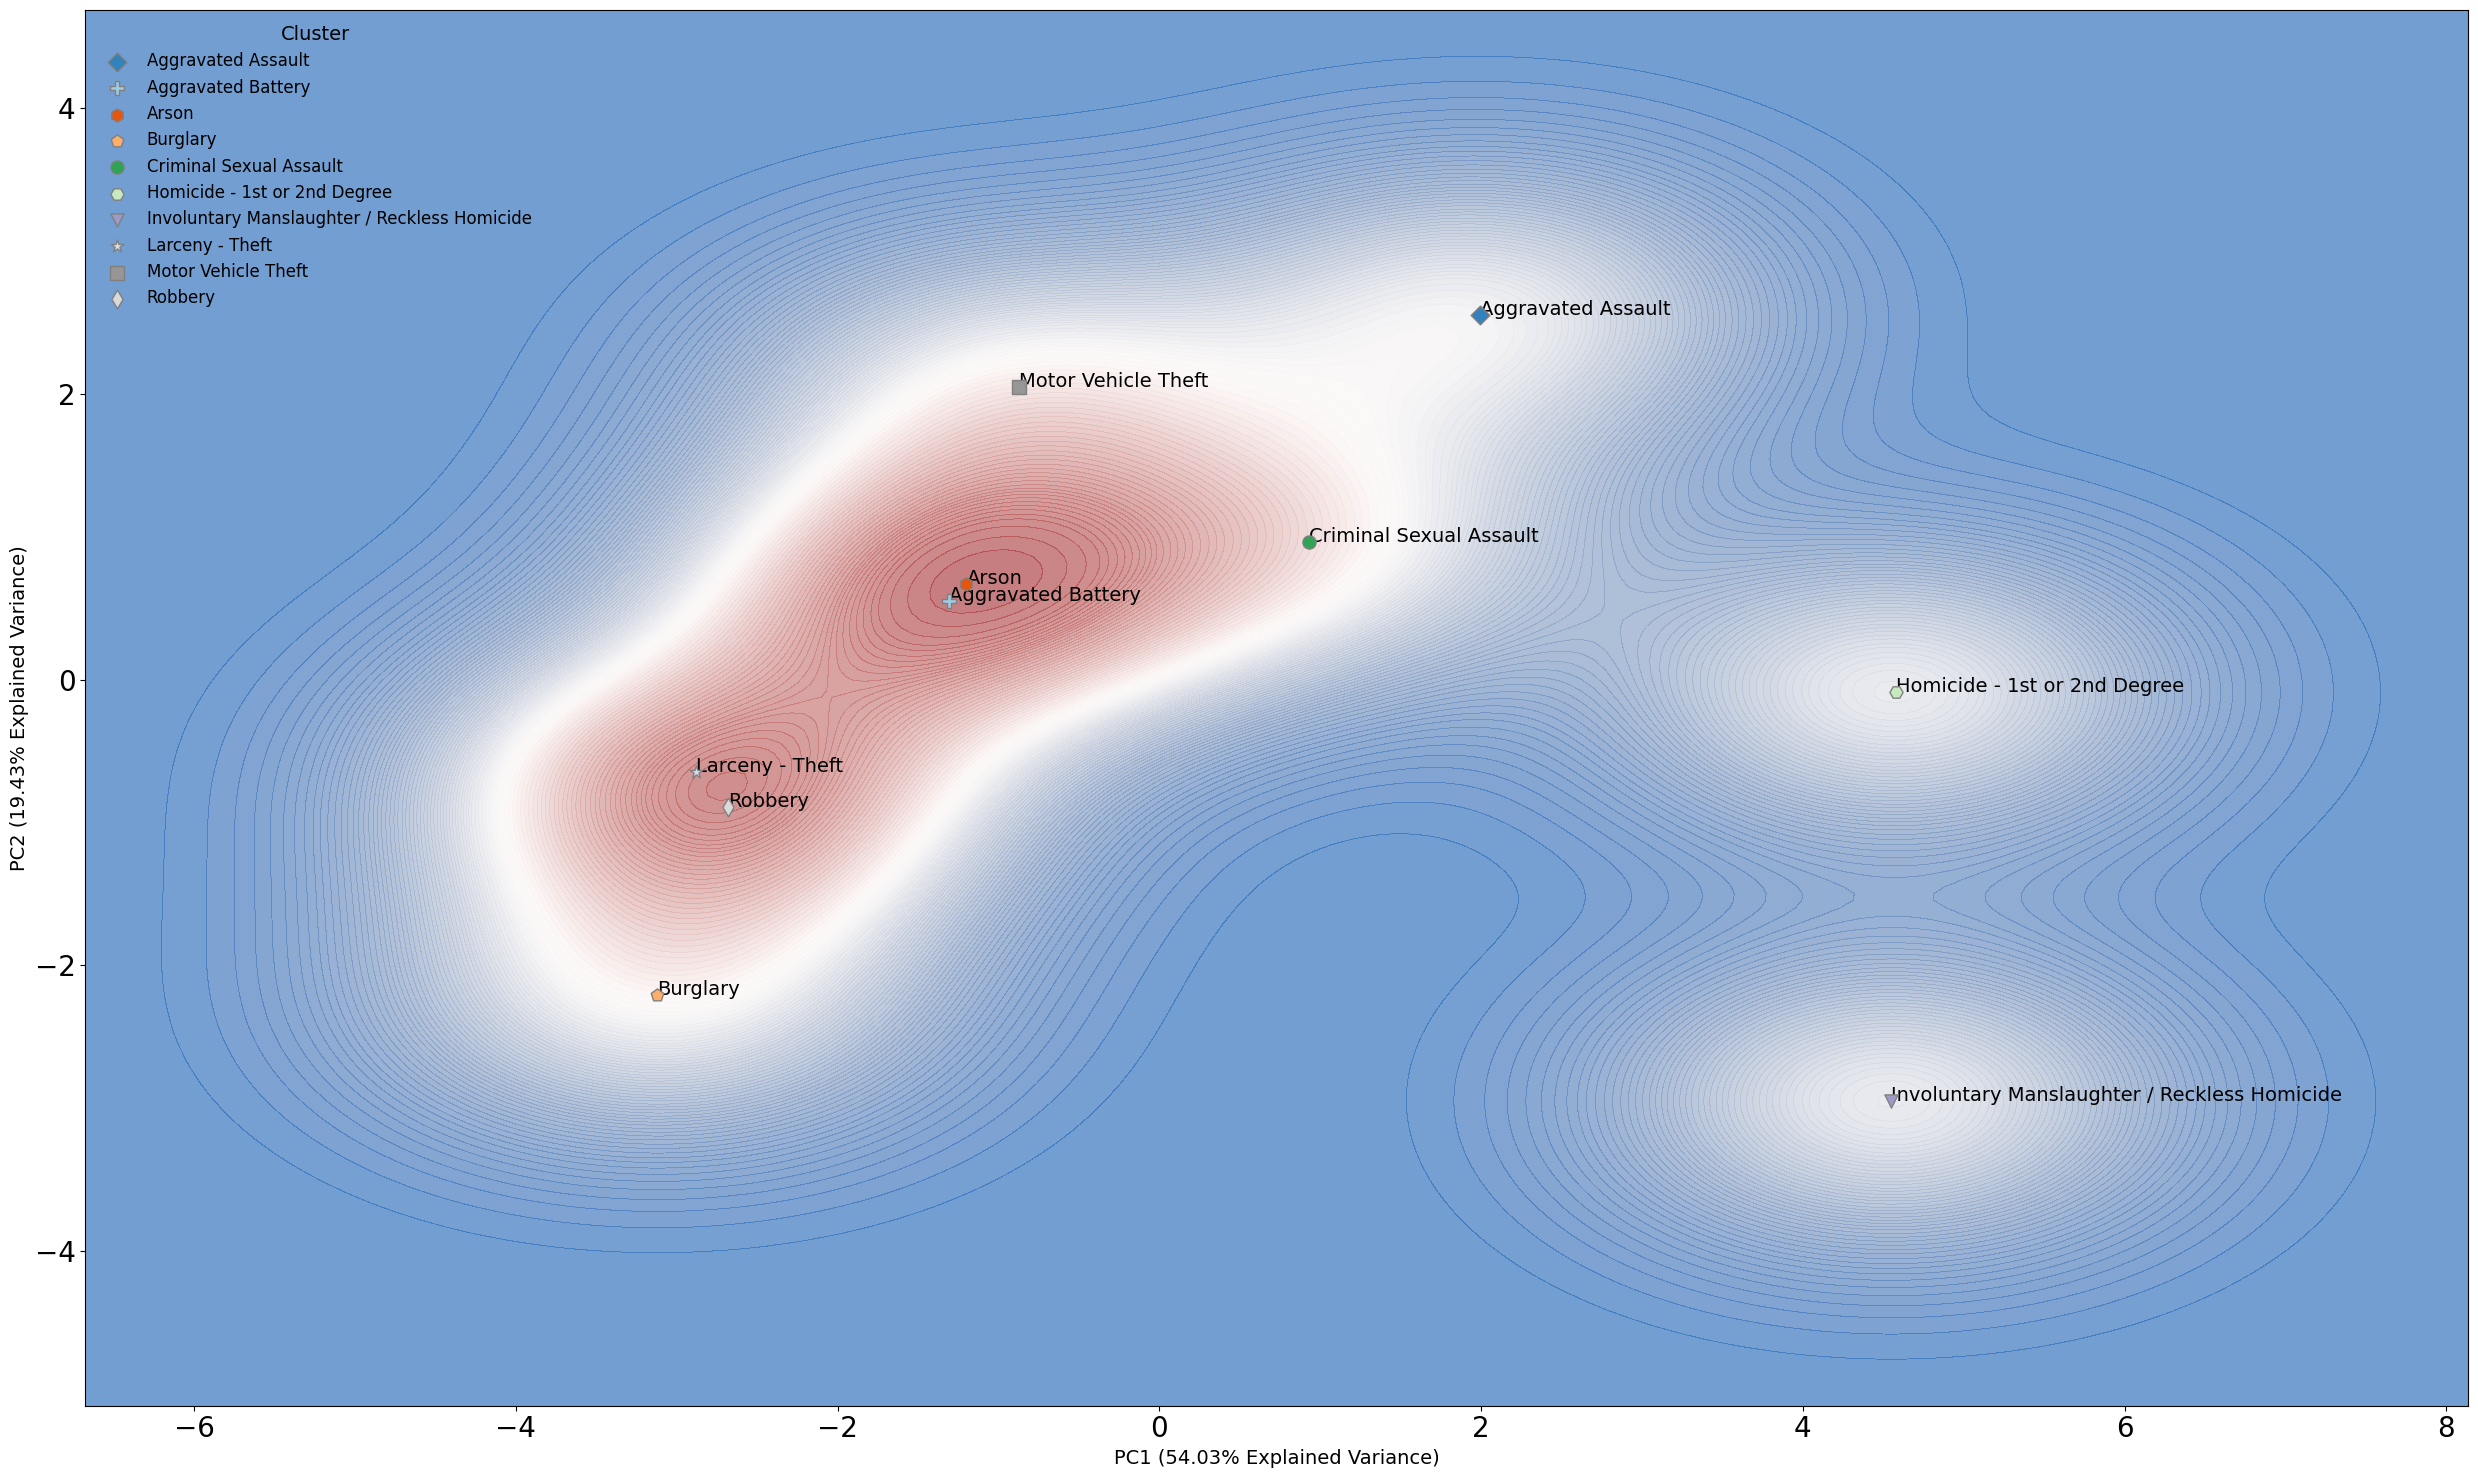

In [17]:
from sklearn.decomposition import PCA

# Initialize variables
n_components = 2

# PCA on z-score matrix (26 X 300)
pca = PCA(n_components=n_components)
coords_pca = pca.fit_transform(z_df_i.values)

# plot
_ = plot.fancy_pca_plot(data=z_df_i, pc_scores=coords_pca, pca_model_object=pca, labels=z_df_i.index.values, file='indexed_pca')

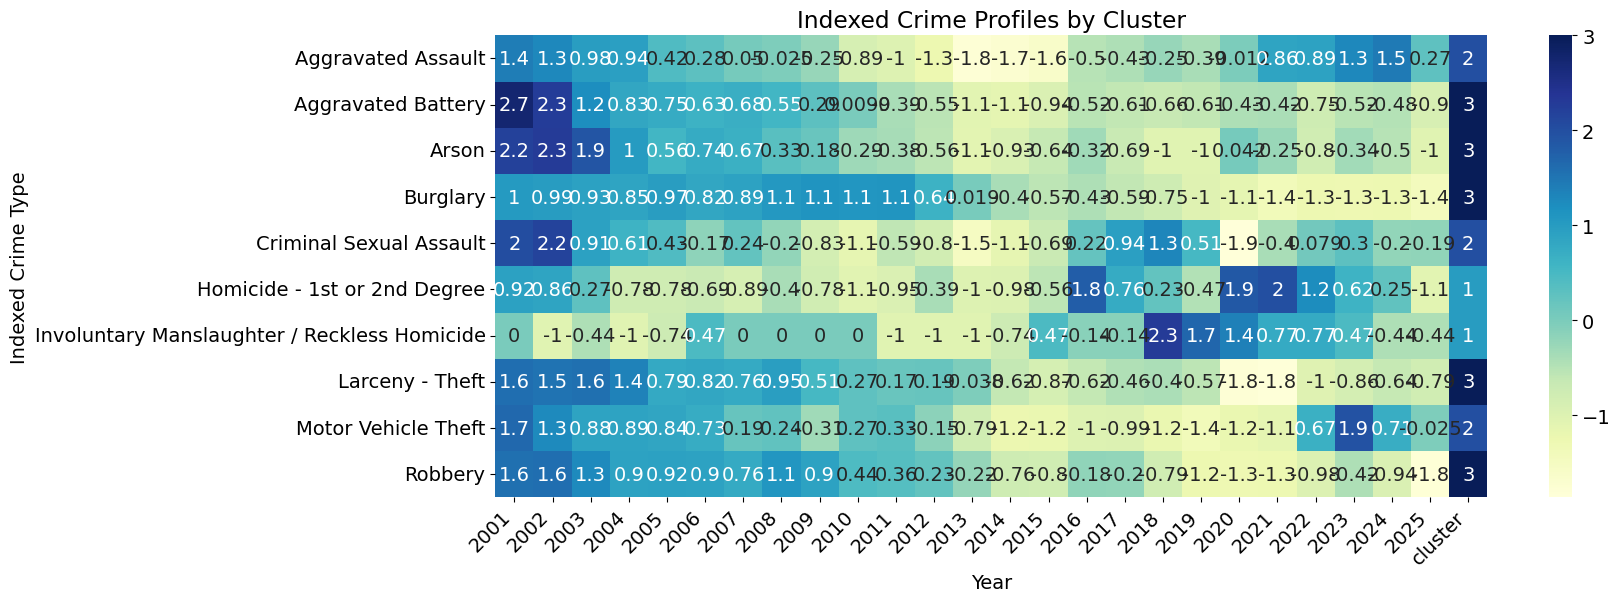

In [18]:
df_labeled = z_df_i.copy()
df_labeled["cluster"] = clusters

# plot
plt.figure(figsize=(16, 6))
sns.heatmap(df_labeled, annot=True, cmap="YlGnBu")
plt.title("Indexed Crime Profiles by Cluster")
plt.xlabel("Year")
plt.ylabel("Indexed Crime Type")
plt.xticks(rotation=45, ha='right')
plt.show()

In [19]:
# centroid
centroids = df_labeled.groupby("cluster").mean()
centroids

year,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
cluster,,,,,,,,,,,,,,,,,,,,,
1,0.461968,-0.094380,-0.086001,-0.910905,-0.759404,-0.111313,-0.442944,-0.198828,-0.392437,-0.527121,...,0.827308,0.309615,1.260668,0.604120,1.622691,1.387032,0.999814,0.545274,-0.094419,-0.759424
2,1.702790,1.574247,0.922945,0.812722,0.563278,0.279156,0.161033,0.007943,-0.464410,-0.586077,...,-0.428419,-0.160997,-0.055020,-0.419264,-1.032934,-0.217044,0.547571,1.174328,0.652949,0.017816
3,1.820730,1.731359,1.371215,0.990176,0.799020,0.782097,0.752264,0.795633,0.602990,0.302656,...,-0.413848,-0.509736,-0.729051,-0.892107,-0.918200,-1.030102,-0.961906,-0.684137,-0.764359,-1.200691


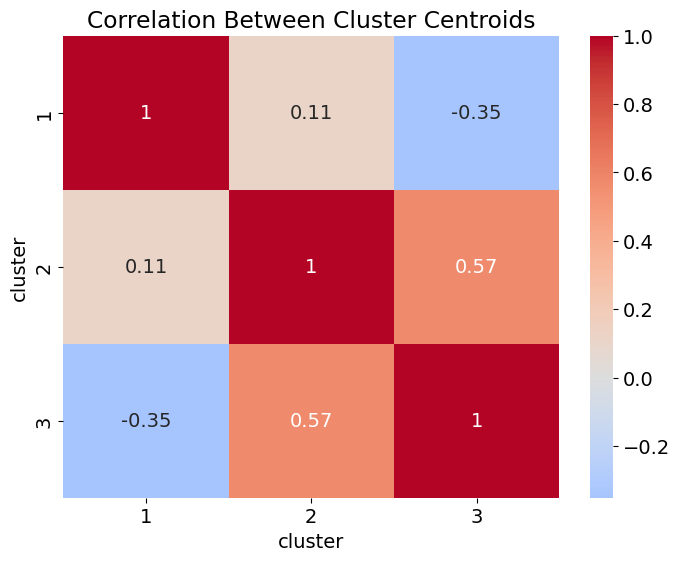

In [20]:
# Calculate correlation between the cluster profiles
centroid_corr = centroids.T.corr()

plt.figure(figsize=(8,6))
sns.heatmap(centroid_corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Between Cluster Centroids")
plt.show()

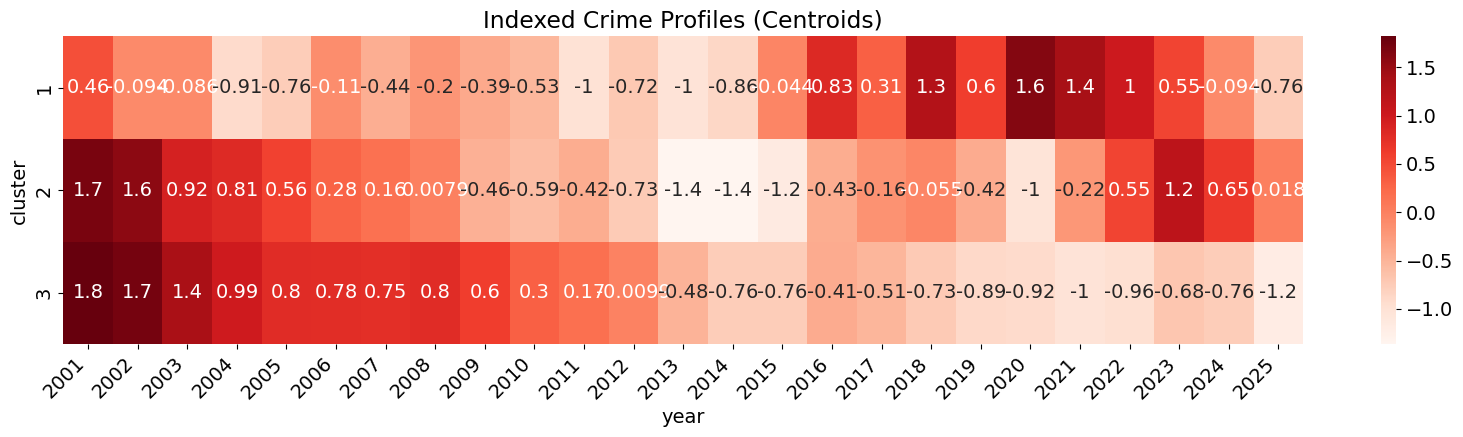

In [21]:
plt.figure(figsize=(20,4))
sns.heatmap(centroids, annot=True, cmap="Reds")
plt.title("Indexed Crime Profiles (Centroids)")
plt.xticks(rotation=45, ha='right')
# Save the figure with high resolution and tight cropping
plt.savefig("../Image/cluster_centroids_analysis.png", dpi=600, bbox_inches='tight')
plt.show()

#### Insights & Observations

Note: The observations below describe cluster centroid trajectories from the final chosen configuration: correlation distance + complete linkage, 3 clusters (silhouette = 0.447). Cluster labels match the final output: Cluster 1: Lethal Violence; Cluster 2: Interpersonal Violence + Motor Vehicle Theft, Cluster 3: Property Crime + Related Offenses.

* **Inverse relationship (Cluster 1 vs. Cluster 3):** Cluster 1 (Lethal Violence) and Cluster 3 (Property Crime) often move in opposite directions. In 2020, Cluster 1 reached a centroid high of 1.62 while Cluster 3 reached a low of -0.91, consistent with the pandemic reducing street-level property crime while lethal violence surged.
* **Cluster 1 - Lethal Violence:** Stayed below average for nearly 15 years, hitting its lowest point around 2013. Surged from 2016, peaked in 2020, and has since trended sharply downward centroid stood at -0.105 by 2025, approaching its pre-pandemic baseline.
* **Cluster 2 - Interpersonal Violence + Motor Vehicle Theft:** Elevated in the early 2000s, crashed between 2012 and 2015, briefly surged in the late 2010s, and is currently drifting back into negative territory.
* **Cluster 3 - Property Crime + Related Offenses:** Maintained high positive values for the first decade (2001–2011). Since 2014, it has been in long-term decline and has remained the lowest performing group for several years.
* **2025 trend** - All three clusters show a downward trend as of 2025. Cluster 1, which was dominant during the pandemic years, has crashed back down to a centroid of -0.105, approaching its pre-pandemic baseline.
* **Volatility:** Cluster 1 shows the most dramatic swing, moving from deep negatives in the early 2010s to the sharpest positives during the pandemic years, then back down - a full arc no other cluster matches.

### Summary (Indexed Crimes) <a id="Indexed"></a>
#### Correlation Distance + Complete Linkage on Z‑Scored Crime Time Series
This analysis examines how indexed crime categories in the dataset move over time by applying hierarchical clustering to **Z‑scored time series** using **correlation distance** and **complete linkage**. This configuration isolates **patterns of co‑movement**, allowing us to identify crime types that rise and fall together relative to their own historical baselines.

#### Key Insight
The resulting clusters do **not** reflect crime volume or severity. Instead, they reveal **synchronized temporal behavior**, crime types that tend to spike, dip, or shift together. These shared patterns often point to common underlying drivers such as environmental conditions, social dynamics, or policy changes.

#### Cluster Findings
##### Cluster 1: Lethal Violence
* Homicide – 1st or 2nd Degree
* Involuntary Manslaughter / Reckless Homicide
    * These offenses show tightly aligned anomaly patterns. When one deviates from its norm, the other typically does as well. This suggests shared situational or behavioral dynamics influencing lethal outcomes.
##### Cluster 2: Interpersonal Violence + Motor Vehicle Theft
* Aggravated Assault
* Criminal Sexual Assault
* Motor Vehicle Theft
    * Despite spanning both violent and property crime, these categories exhibit remarkably similar temporal rhythms. All three surged post-2020 and remain elevated relative to their pre-pandemic baselines. One plausible explanation is that the post-pandemic disruption to routine activity reduced street presence, weakened guardianship, and shifts in vehicle availability and usage patterns created conditions that simultaneously elevated interpersonal conflict and opportunistic vehicle theft. The clustering result suggests these are not independent trends and may be worth analyzing together in downstream modeling.

##### Cluster 3: Property Crime + Related Offenses
* Aggravated Battery
* Arson
* Burglary
* Larceny – Theft
* Robbery
    * This larger cluster reflects a group of offenses that share long‑term trends and seasonal patterns. Their synchronized behavior suggests they respond similarly to opportunity structures, economic conditions, or shifts in routine activity patterns.
##### Conclusion
Using Z‑scores with correlation distance and complete linkage reveals meaningful structure in the temporal behavior of crime categories. The clusters represent **coherent groups of crimes that move together over time**, offering valuable insight for forecasting, operational planning, and strategic decision‑making.